# Task 2 — Tier C (optimized): both transformers, one pipeline

### This is the optimized version of the previous notebook. Here we:
Replace the two duplicated model blocks with a single parameterized loop. Train the DistilBERT + RoBERTa identically, evaluate each on the test set and the held-out probes, and build a comparison table that makes the core point explicit: in-distribution accuracy saturates at ~100% for every model, so the probes, not test accuracy, are the real measure of what was learned.

In [1]:
%pip install -q transformers peft datasets accelerate scikit-learn captum

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json, numpy as np, pandas as pd, torch
from pathlib import Path
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

DATA = Path("data/dataset")
def load_jsonl(p): return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
train, val, test = (pd.DataFrame(load_jsonl(DATA/f"{s}.jsonl")) for s in ("train","val","test"))

# Per-model config: the ONLY difference is the attention module names LoRA targets.
MODEL_ZOO = {
    "distilbert": {"hf": "distilbert-base-uncased", "targets": ["q_lin", "v_lin"]},
    "roberta":    {"hf": "roberta-base",            "targets": ["query", "value"]},
}

c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model-agnostic helpers (train + probe)

In [3]:
def make_tokenizer(hf_name):
    return AutoTokenizer.from_pretrained(hf_name)

def to_ds(df, tok, label_col="class_id"):
    d = Dataset.from_pandas(df[["text", label_col]].rename(columns={label_col: "labels"}))
    return d.map(lambda b: tok(b["text"], truncation=True, max_length=256), batched=True)

def metrics(eval_pred):
    logits, labels = eval_pred
    p = np.argmax(logits, axis=1)
    return {"acc": accuracy_score(labels, p), "f1": f1_score(labels, p, average="macro")}

def build_lora_model(hf_name, targets, n_labels):
    base = AutoModelForSequenceClassification.from_pretrained(hf_name, num_labels=n_labels)
    cfg = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                     target_modules=targets)
    m = get_peft_model(base, cfg)
    m.print_trainable_parameters()
    return m

def train_one(name, cfg, train_df, val_df, test_df, n_labels, tag):
    tok = make_tokenizer(cfg["hf"])
    dtr, dva, dte = to_ds(train_df, tok), to_ds(val_df, tok), to_ds(test_df, tok)
    model = build_lora_model(cfg["hf"], cfg["targets"], n_labels)
    args = TrainingArguments(output_dir=f"tierC_{name}_{tag}", num_train_epochs=4,
                             per_device_train_batch_size=16, per_device_eval_batch_size=32,
                             eval_strategy="epoch", logging_strategy="epoch", save_strategy="epoch",
                             load_best_model_at_end=True, metric_for_best_model="f1",
                             learning_rate=2e-4, report_to="none")
    trainer = Trainer(model=model, args=args, train_dataset=dtr, eval_dataset=dva,
                      data_collator=DataCollatorWithPadding(tok), compute_metrics=metrics)
    trainer.train()
    p = np.argmax(trainer.predict(dte).predictions, axis=1)
    acc = accuracy_score(dte["labels"], p); f1 = f1_score(dte["labels"], p, average="macro")
    print(f"[{name} · {tag}] test acc={acc:.3f} f1={f1:.3f}")
    print(confusion_matrix(dte["labels"], p))
    model.save_pretrained(f"models/tierC_{name}_{tag}")
    hist = pd.DataFrame(trainer.state.log_history)
    return {"model": name, "tag": tag, "test_acc": acc, "test_f1": f1,
            "trainer": trainer, "tok": tok, "model_obj": model, "hist": hist}

def probe_eval(res):
    tok, model = res["tok"], res["model_obj"].eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"; model.to(device)
    def predict(text):
        enc = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
        with torch.no_grad():
            return int(model(**enc).logits.argmax(1))
    out = {}
    for probe in ["probe_modern_human", "probe_sop"]:
        rows = load_jsonl(Path("data/dataset")/f"{probe}.jsonl")
        preds = [predict(r["text"]) for r in rows]
        counts = np.bincount(preds, minlength=3)
        out[probe] = counts
        pct_human = 100 * counts[0] / counts.sum()
        print(f"  [{res['model']}] {probe}: classes {counts.tolist()} | {pct_human:.0f}% labelled human")
    return out

## Running BOTH models through the same pipeline (tertiary 3-class)

In [4]:
results = []
for name, cfg in MODEL_ZOO.items():
    print("=" * 60)
    print(f"Training {name}")
    res = train_one(name, cfg, train, val, test, n_labels=3, tag="tertiary")
    print("Probe diagnostics:")
    res["probes"] = probe_eval(res)
    results.append(res)

Training distilbert


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6438.51it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.287631,0.011554,1.000000,1.000000
2,0.008662,0.002415,1.000000,1.000000
3,0.004645,0.001806,1.000000,1.000000
4,0.003154,0.001513,1.000000,1.000000


...

trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.601261,0.047505,0.978836,0.978694
2,0.013524,0.004752,1.000000,1.000000
3,0.002503,0.000520,1.000000,1.000000
4,0.000940,0.000621,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned m

[roberta · tertiary] test acc=1.000 f1=1.000
[[63  0  0]
 [ 0 63  0]
 [ 0  0 63]]
Probe diagnostics:
  [roberta] probe_modern_human: classes [52, 0, 8] | 87% labelled human
  [roberta] probe_sop: classes [0, 10, 1] | 0% labelled human


## The comparison table which is the main point for this notebook

In [ ]:
rows = []
for r in results:
    mh = r["probes"]["probe_modern_human"]; sop = r["probes"]["probe_sop"]
    rows.append({
        "model": r["model"],
        "test_acc": round(r["test_acc"], 3),
        "test_f1": round(r["test_f1"], 3),
        "modern_human_%human": round(100*mh[0]/mh.sum(), 1),
        "modern_human_misclassified_AI": int(mh[1] + mh[2]),
        "SOP_%human": round(100*sop[0]/sop.sum(), 1),
    })
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
comparison.to_csv("output/task-2/results_tierc_comparison.csv", index=False)


     model  test_acc  test_f1  modern_human_%human  modern_human_misclassified_AI  SOP_%human
distilbert       1.0      1.0                 70.0                             18         0.0
   roberta       1.0      1.0                 86.7                              8         0.0


READING THIS TABLE (the core finding):
- Both models reach ~100% test accuracy -> the in-distribution task is trivially
  separable for transformers; test accuracy does NOT discriminate between models.
- The probes do: a model that scores 100% on test but mislabels held-out modern
  human prose (and the SOP) as AI has learned register/era, not authorship.
- Therefore the probe columns, not test_acc, are the real evaluation. This is the
  whole point of the genre-matched design + held-out probes from Task 0.

## Loss curves (per model)

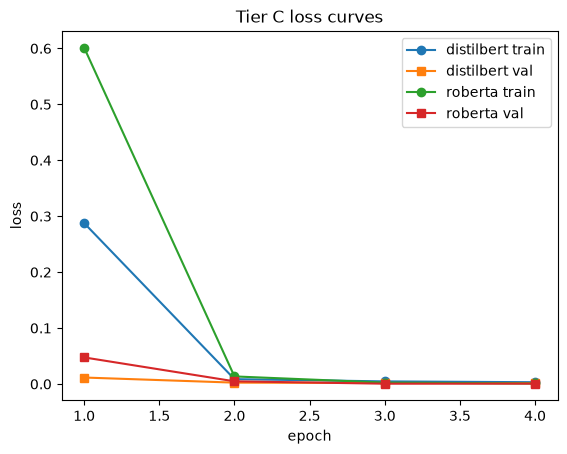

In [ ]:
import matplotlib.pyplot as plt
for r in results:
    h = r["hist"]; tr = h.dropna(subset=["loss"]); ev = h.dropna(subset=["eval_loss"])
    plt.plot(tr["epoch"], tr["loss"], marker="o", label=f"{r['model']} train")
    plt.plot(ev["epoch"], ev["eval_loss"], marker="s", label=f"{r['model']} val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Tier C loss curves")
plt.savefig("output/task-2/results_tierc_loss.png", dpi=120); plt.show()

## Binary framing: human vs styled (the imposter test)
Same loop, remapped labels: drop neutral, keep human(0) vs styled(2). This is the hardest *useful* binary framing; can the model tell a real author from an AI imitating that author?

In [8]:
def remap(df, mapping):
    d = df.copy(); d["class_id"] = d["class_id"].map(mapping)
    return d[d["class_id"] >= 0].reset_index(drop=True)

# human(0) vs styled(2) -> drop neutral(1)
MAP_HS = {0:0, 1:-1, 2:1}
tr_hs, va_hs, te_hs = remap(train, MAP_HS), remap(val, MAP_HS), remap(test, MAP_HS)
print(f"human-vs-styled sizes: train {len(tr_hs)} val {len(va_hs)} test {len(te_hs)}")

results_hs = []
for name, cfg in MODEL_ZOO.items():
    print("=" * 60)
    print(f"Training {name} (human-vs-styled)")
    res = train_one(name, cfg, tr_hs, va_hs, te_hs, n_labels=2, tag="human_vs_styled")
    results_hs.append(res)

human-vs-styled sizes: train 588 val 126 test 126
Training distilbert (human-vs-styled)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4026.79it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.231619,0.004203,1.000000,1.000000
2,0.008069,0.000586,1.000000,1.000000
3,0.005197,0.000452,1.000000,1.000000
4,0.005128,0.000329,1.000000,1.000000


...

trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.402457,0.021691,0.992063,0.992063
2,0.003163,0.000007,1.000000,1.000000
3,0.000320,0.000079,1.000000,1.000000
4,0.000187,0.000003,1.000000,1.000000


c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned m

[roberta · human_vs_styled] test acc=1.000 f1=1.000
[[63  0]
 [ 0 63]]


## Probe testing (consolidated)
The tertiary models were already probed in the loop above. Here we surface the probe predictions for the tertiary models side by side, as the honest evaluation. (Binary human-vs-styled has no "neutral" class, so the 3-way probe read below uses the tertiary models.)

In [ ]:
probe_rows = []
for r in results:
    for probe in ["probe_modern_human", "probe_sop"]:
        c = r["probes"][probe]
        probe_rows.append({"model": r["model"], "probe": probe,
                           "human": int(c[0]), "neutral": int(c[1]), "styled": int(c[2]),
                           "%human": round(100*c[0]/c.sum(), 1)})
probe_table = pd.DataFrame(probe_rows)
print(probe_table.to_string(index=False))
probe_table.to_csv("output/task-2/results_probe_predictions.csv", index=False)

     model              probe  human  neutral  styled  %human
distilbert probe_modern_human     42        0      18    70.0
distilbert          probe_sop      0       11       0     0.0
   roberta probe_modern_human     52        0       8    86.7
   roberta          probe_sop      0       10       1     0.0


## Saliency: what tokens drive the prediction (Captum)
Layer Integrated Gradients on the chosen final model. Run on a styled-AI imposter and on the SOP, to see whether the "AI" signal is modern domain vocabulary (era/register leak) or generative-cliche words (real AI signal).

### Distilbert

In [ ]:
from captum.attr import LayerIntegratedGradients

FINAL = next(r for r in results if r["model"] == "distilbert")
tok, model = FINAL["tok"], FINAL["model_obj"].eval()
device = "cuda" if torch.cuda.is_available() else "cpu"; model.to(device)

def fwd(input_ids, attention_mask):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(fwd, model.get_input_embeddings())

def saliency(text, top_k=12):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    target = int(model(**enc).logits.argmax(1))
    ref = torch.full_like(enc["input_ids"], tok.pad_token_id)
    att = lig.attribute(inputs=enc["input_ids"], baselines=ref,
                        additional_forward_args=(enc["attention_mask"],),
                        target=target, n_steps=32)
    scores = att.sum(-1).squeeze(0).detach().cpu().numpy()
    toks = tok.convert_ids_to_tokens(enc["input_ids"].squeeze(0))
    pairs = [(t, s) for t, s in zip(toks, scores) if t not in ("[CLS]","[SEP]","[PAD]","<s>","</s>","<pad>")]
    top = sorted(pairs, key=lambda x: -x[1])[:top_k]
    print(f"predicted class {target} (0=human 1=neutral 2=styled)")
    print("top tokens pushing this class:", [t for t, _ in top])
    return top

In [ ]:
# saliency on a few styled-AI imposters
styled_examples = test[test.label == "ai_styled"]["text"].head(2).tolist()
for t in styled_examples:
    print("=" * 60); print(t[:140], "..."); saliency(t)

# saliency on the SOP
print("#" * 60)
print("SOP saliency")
print("#" * 60)
sop = load_jsonl(Path("data/dataset") / "probe_sop.jsonl")
for r in sop[:3]:
    print("=" * 60); print(r["text"][:140], "..."); saliency(r["text"])

It was an era of ardent affection, it was an era of callous indifference, it was the season of unbridled happiness, it was the season of pro ...
predicted class 2 (0=human 1=neutral 2=styled)
top tokens pushing this class: ['human', 'we', 'human', ',', 'of', 'love', 'in', '.', 'truth', 'spirit', 'our', 'the']
It was a season of sorrow, it was a season of longing, it was the age of departure, it was the age of nostalgia. It is a poignant truth that ...
predicted class 2 (0=human 1=neutral 2=styled)
top tokens pushing this class: ['human', 'to', '.', 'human', 'as', 'the', 'spirit', 'the', 'in', ',', ',', 'must']
############################################################
SOP saliency
############################################################
There are some labs you discover and think, “this is interesting.” And then there are a few rare
ones that make you feel, almost immediately ...
predicted class 1 (0=human 1=neutral 2=styled)
top tokens pushing this class: ['not', '“', 'not', 'lea